## Калька с Matlab для примера

2.021296262741089


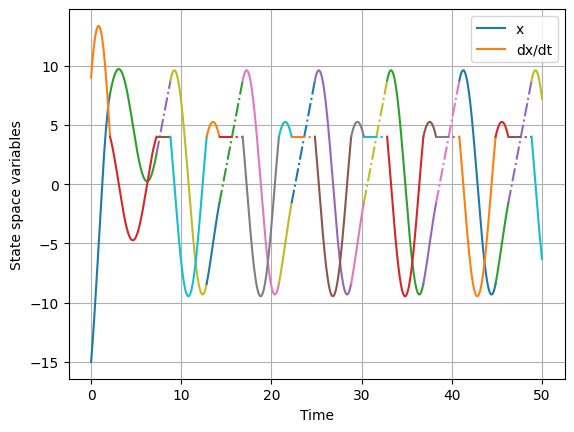

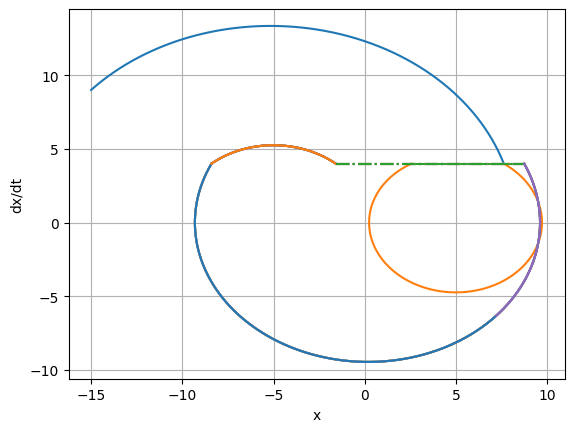

In [5]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# параметры
T0 = 0.0
Tf = 50.0
c = 1.0
k = 0.02
m = 1.0
nu = 0.5
nuf = 1.8 * nu
g = 9.8
v = 4.0
dt = 1e-5
x0 = np.array([-15.0, 9.0], dtype=float)
dt_max = 0.0005


def ft(t, y, c, k, m, g, nu, v, sgn):
    f = np.zeros(2, dtype=float)
    f[0] = y[1]
    f[1] = -c / m * y[0] - k / m * y[1] - nu * g * sgn
    return f


def events(t, y, c, k, m, g, nu, v, sgn):
    return y[1] - v


events.terminal = True
events.direction = 0


# подготовка рисунков
plt.figure(1)
plt.clf()

plt.figure(2)
plt.clf()

tt0 = time.time()
sgn = np.sign(x0[1] - v)
# print(sgn)

prev_T0 = -np.inf

while T0 < Tf:
    if T0 <= prev_T0:
        print("Остановка: время перестало расти")
        break
    prev_T0 = T0

   #  print(sgn)

    sol = solve_ivp(
        ft,
        (T0, Tf),
        x0,
        args=(c, k, m, g, nu, v, sgn),
        events=events,
        dense_output=False,
        max_step=dt_max,
    )

    T = sol.t
    Y = sol.y.T

    plt.figure(1)
    plt.plot(T, Y)

    plt.figure(2)
    plt.plot(Y[:, 0], Y[:, 1])

    if (T[-1] >= Tf) or (sol.t_events[0].size == 0):
        break

    TE = sol.t_events[0]
    YE = sol.y_events[0]

    x0 = YE[-1].copy()
    T0 = TE[-1]

    # шаг с поверхности события
    f0 = ft(T0, x0, c, k, m, g, nu, v, sgn)
    x0 = x0 + dt * f0
    T0 = T0 + dt

    sgn = np.sign(x0[1] - v)
    if sgn == 0:
        sgn = -1.0

    q = c * x0[0] + k * x0[1]

    if abs(q) < nu * m * g:
        Tr = (nuf * m * g / c * np.sign(v) - k * v / c - x0[0]) / v

        if Tr > 0:
            t = T0 + np.linspace(0.0, Tr, 50)
            y1 = x0[0] + v * (t - T0)
            y2 = v * np.ones_like(t)

            plt.figure(1)
            plt.plot(t, np.column_stack([y1, y2]), "-.")

            plt.figure(2)
            plt.plot(y1, y2, "-.")

            x0 = np.array([y1[-1], y2[-1]], dtype=float)
            T0 = t[-1]

            sgn = -1.0
    else:
        if len(Y) >= 3:
            sgn = -np.sign(Y[-3, 1] - v)
        else:
            sgn = -np.sign(Y[-1, 1] - v)

elapsed = time.time() - tt0
print(elapsed)

plt.figure(1)
plt.xlabel("Time")
plt.ylabel("State space variables")
plt.legend(["x", "dx/dt"])
plt.grid(True)

plt.figure(2)
plt.xlabel("x")
plt.ylabel("dx/dt")
plt.grid(True)

plt.show()

Elapsed: 2.255344 s


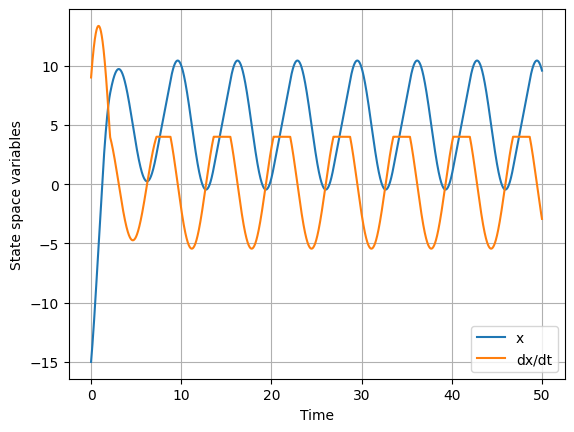

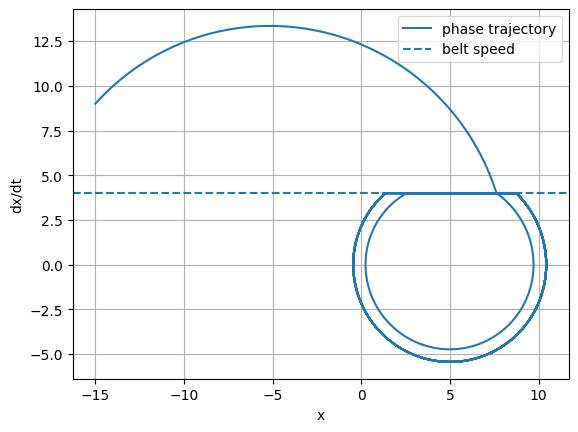

In [6]:
import time
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# параметры
T0 = 0.0
Tf = 50.0
c = 1.0
k = 0.02
m = 1.0
nu = 0.5
nuf = 1.8 * nu
g = 9.8
v = 4.0
dt = 1e-5
dt_max = 5e-4
x0 = np.array([-15.0, 9.0], dtype=float)


# правая часть
def ft(t, y, c, k, m, g, nu, v, sgn):
    x, dx = y
    return np.array([
        dx,
        -c / m * x - k / m * dx - nu * g * sgn
    ], dtype=float)


# событие: скорость тела сравнялась со скоростью ленты
def events(t, y, c, k, m, g, nu, v, sgn):
    return y[1] - v


events.terminal = True
events.direction = 0


# накопители решения
T_parts = []
Y_parts = []

tt0 = time.time()
prev_T0 = -np.inf
sgn = np.sign(x0[1] - v)
if sgn == 0:
    sgn = -1.0

while T0 < Tf:
    if T0 <= prev_T0:
        print("Остановка: время перестало расти")
        break
    prev_T0 = T0

    # участок скольжения
    sol = solve_ivp(
        ft,
        (T0, Tf),
        x0,
        args=(c, k, m, g, nu, v, sgn),
        events=events,
        dense_output=False,
        max_step=dt_max,
    )

    T = sol.t
    Y = sol.y.T

    T_parts.append(T)
    Y_parts.append(Y)

    # если дошли до конца или событие не произошло
    if T[-1] >= Tf or sol.t_events[0].size == 0:
        break

    # точка события
    T0 = float(sol.t_events[0][-1])
    x0 = sol.y_events[0][-1].copy()

    # шаг Эйлера, чтобы сойти с поверхности события
    f0 = ft(T0, x0, c, k, m, g, nu, v, sgn)
    x0 = x0 + dt * f0
    T0 = T0 + dt

    # новый знак
    sgn = np.sign(x0[1] - v)
    if sgn == 0:
        sgn = -1.0

    # проверка условия прилипания
    q = c * x0[0] + k * x0[1]

    if abs(q) < nu * m * g:
        Tr = (nuf * m * g / c * np.sign(v) - k * v / c - x0[0]) / v

        if Tr > 0:
            t = T0 + np.linspace(0.0, Tr, 50)
            y1 = x0[0] + v * (t - T0)
            y2 = np.full_like(t, v)
            Y_stick = np.column_stack((y1, y2))

            T_parts.append(t)
            Y_parts.append(Y_stick)

            x0 = Y_stick[-1].copy()
            T0 = t[-1]
            sgn = -1.0

# склейка кусков
if T_parts:
    T_full = [T_parts[0]]
    Y_full = [Y_parts[0]]

    for t_part, y_part in zip(T_parts[1:], Y_parts[1:]):
        if len(t_part) > 1:
            T_full.append(t_part[1:])
            Y_full.append(y_part[1:])
        else:
            T_full.append(t_part)
            Y_full.append(y_part)

    T_full = np.concatenate(T_full)
    Y_full = np.vstack(Y_full)
else:
    T_full = np.array([])
    Y_full = np.empty((0, 2))

elapsed = time.time() - tt0
print(f"Elapsed: {elapsed:.6f} s")

# график состояний
fig1, ax1 = plt.subplots()
ax1.plot(T_full, Y_full[:, 0], label="x")
ax1.plot(T_full, Y_full[:, 1], label="dx/dt")
ax1.set_xlabel("Time")
ax1.set_ylabel("State space variables")
ax1.grid(True)
ax1.legend()

# фазовый портрет
fig2, ax2 = plt.subplots()
ax2.plot(Y_full[:, 0], Y_full[:, 1], label="phase trajectory")
ax2.axhline(v, linestyle="--", label="belt speed")
ax2.set_xlabel("x")
ax2.set_ylabel("dx/dt")
ax2.grid(True)
ax2.legend()

plt.show()